# Análisis exploratorio — Retención de clientes ISP

Validación de las hipótesis de negocio sobre la tabla `dbo.analitica_cliente`
y construcción de los gráficos de soporte para el dashboard.

In [4]:
import pandas as pd
import urllib.parse
from sqlalchemy import create_engine

# Cadena de conexión en formato ODBC nativo (la misma sintaxis que usaría
# cualquier app .NET o Java para conectarse). Trusted_Connection=yes = usa tu
# sesión de Windows, igual que SSMS.
#
# TrustServerCertificate=yes es la parte nueva: el Driver 18 exige TLS por
# defecto, y una instancia local sin certificado propio no lo tiene. Sin este
# parámetro, la conexión falla con un error de SSL. En un servidor de
# producción real esto NO se pone así — se instala un certificado válido en
# su lugar — pero para desarrollo local es la práctica estándar.
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    r"SERVER=localhost\SQLEXPRESS;"
    "DATABASE=retencion_isp;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

df = pd.read_sql("SELECT * FROM dbo.analitica_cliente", engine)
print(df.shape)
df.head()

(5215, 22)


,id_cliente,tipo_cliente,localidad,nombre_plan,velocidad_mbps,precio_base,canal_alta,fecha_alta,fecha_baja,motivo_baja,...,tickets_total,tickets_tecnicos_total,tickets_tecnicos_90d,mttr_horas,csat,facturas_total,impagas_total,impagas_4m,monto_promedio,ingreso_mensual
0,C1001,Residencial,Mar de Ostende,Básico 50,50,22000.0,Vendedor,2021-08-22,None,NaN,...,14,11,1,53.9,3.55,24,2,0,27730.99,34664.79
1,C1002,Residencial,Mar de Ostende,Básico 50,50,22000.0,Sucursal,2020-07-21,None,NaN,...,11,8,0,26.9,4.00,24,7,2,27664.05,34911.22
2,C1003,Residencial,Cariló,Estándar 100,100,30000.0,Sucursal,2019-04-23,None,NaN,...,8,4,0,15.5,4.75,24,2,0,37842.21,46807.26
3,C1004,Residencial,Pinamar,Estándar 100,100,30000.0,Sucursal,2023-05-19,None,NaN,...,8,5,0,28.1,4.50,24,6,0,34600.36,46419.49
4,C1005,Residencial,Pinamar,Básico 50,50,22000.0,Sucursal,2021-10-14,None,NaN,...,9,4,0,17.1,4.75,24,1,0,27643.38,34377.39


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5215 entries, 0 to 5214
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              5215 non-null   str    
 1   tipo_cliente            5215 non-null   str    
 2   localidad               5215 non-null   str    
 3   nombre_plan             5215 non-null   str    
 4   velocidad_mbps          5215 non-null   int64  
 5   precio_base             5215 non-null   float64
 6   canal_alta              5215 non-null   str    
 7   fecha_alta              5215 non-null   object 
 8   fecha_baja              1133 non-null   object 
 9   motivo_baja             1133 non-null   str    
 10  churn                   5215 non-null   int64  
 11  antiguedad_meses        5215 non-null   int64  
 12  tickets_total           5215 non-null   int64  
 13  tickets_tecnicos_total  5215 non-null   int64  
 14  tickets_tecnicos_90d    5215 non-null   int64  
 15

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_cliente,5215,5215,C1001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_cliente,5215,2,Residencial,4630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localidad,5215,6,Pinamar,2120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_plan,5215,6,Estándar 100,1464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
velocidad_mbps,5215.0,NaN,NaN,NaN,299.213806,286.037696,50.0,100.0,100.0,500.0,1000.0
precio_base,5215.0,NaN,NaN,NaN,43567.59348,22603.382756,22000.0,30000.0,30000.0,58000.0,95000.0
canal_alta,5215,5,Sucursal,1770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_alta,5215,2416,2022-11-07,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_baja,1133,569,2026-04-26,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
motivo_baja,1133,7,Precio,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['fecha_alta'] = pd.to_datetime(df['fecha_alta'])
df['fecha_baja'] = pd.to_datetime(df['fecha_baja'])

df.dtypes[['fecha_alta', 'fecha_baja']]

fecha_alta    datetime64[s]
fecha_baja    datetime64[s]
dtype: object

In [ ]:
# VERSIÓN INCORRECTA — deliberadamente, para exponer el sesgo de exposición.
bins = [-1, 0, 2, 5, 100]
labels = ['0', '1-2', '3-5', '6+']

df['bucket_tickets_total'] = pd.cut(df['tickets_tecnicos_total'], bins=bins, labels=labels)

churn_incorrecto = df.groupby('bucket_tickets_total', observed=True)['churn'].agg(
    clientes='size',
    churn_pct=lambda s: round(s.mean() * 100, 1)
)
churn_incorrecto

,clientes,churn_pct
bucket_tickets_total,,
0,499,49.3
1-2,1397,32.9
3-5,2256,14.8
6+,1063,8.8


In [9]:
df['bucket_tickets_90d'] = pd.cut(df['tickets_tecnicos_90d'], bins=[-1, 0, 1, 2, 100],
                                    labels=['0', '1', '2', '3+'])

churn_correcto = df.groupby('bucket_tickets_90d', observed=True)['churn'].agg(
    clientes='size',
    churn_pct=lambda s: round(s.mean() * 100, 1)
)
churn_correcto

,clientes,churn_pct
bucket_tickets_90d,,
0,3014,16.2
1,1635,25.4
2,442,36.4
3+,124,56.5


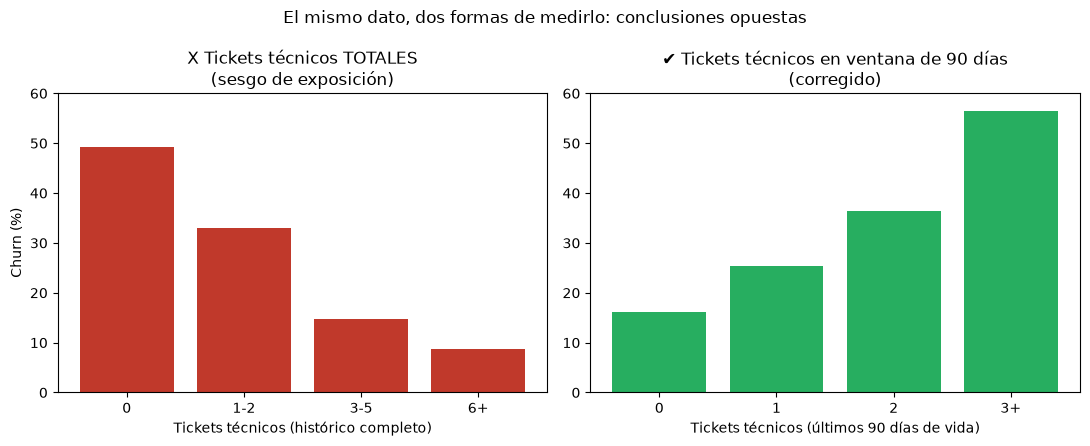

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(churn_incorrecto.index.astype(str), churn_incorrecto['churn_pct'], color='#c0392b')
axes[0].set_title('X Tickets técnicos TOTALES\n(sesgo de exposición)')
axes[0].set_ylabel('Churn (%)')
axes[0].set_xlabel('Tickets técnicos (histórico completo)')

axes[1].bar(churn_correcto.index.astype(str), churn_correcto['churn_pct'], color='#27ae60')
axes[1].set_title('✔ Tickets técnicos en ventana de 90 días\n(corregido)')
axes[1].set_xlabel('Tickets técnicos (últimos 90 días de vida)')

for ax in axes:
    ax.set_ylim(0, 60)

fig.suptitle('El mismo dato, dos formas de medirlo: conclusiones opuestas', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/sesgo_exposicion.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
churn_localidad = df.groupby('localidad', observed=True)['churn'].agg(
    clientes='size',
    churn_pct=lambda s: round(s.mean() * 100, 1)
).sort_values('churn_pct', ascending=False)

churn_localidad

,clientes,churn_pct
localidad,,
Mar de Ostende,499,30.5
Valeria del Mar,787,26.0
General Madariaga,437,24.7
Cariló,588,23.5
Ostende,784,21.3
Pinamar,2120,17.1


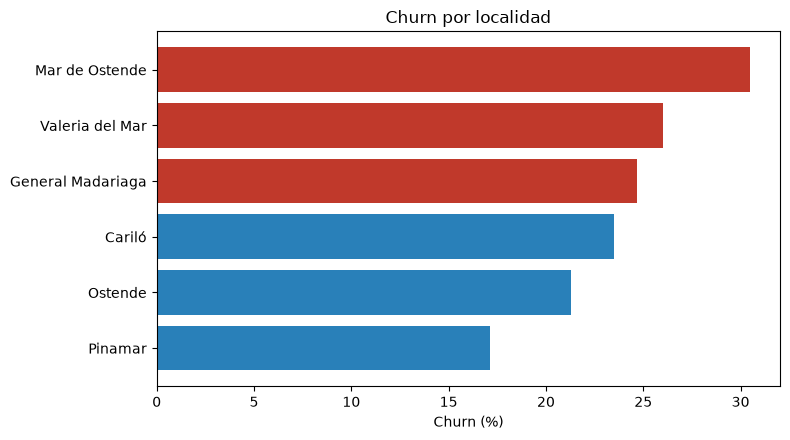

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colores = ['#c0392b' if v > churn_localidad['churn_pct'].mean() else '#2980b9'
           for v in churn_localidad['churn_pct']]
ax.barh(churn_localidad.index, churn_localidad['churn_pct'], color=colores)
ax.set_xlabel('Churn (%)')
ax.set_title('Churn por localidad')
ax.invert_yaxis()  # para que la de mayor churn quede arriba
plt.tight_layout()
plt.savefig('../docs/churn_localidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
bins_mora = [-1, 0, 1, 2, 100]
labels_mora = ['0', '1', '2', '3+']
df['bucket_mora'] = pd.cut(df['impagas_4m'], bins=bins_mora, labels=labels_mora)

churn_mora = df.groupby('bucket_mora', observed=True)['churn'].agg(
    clientes='size',
    churn_pct=lambda s: round(s.mean() * 100, 1)
)
churn_mora

,clientes,churn_pct
bucket_mora,,
0,2810,18.1
1,1586,21.8
2,604,30.0
3+,215,45.1


In [14]:
bins_ant = [-1, 12, 36, 60, 300]
labels_ant = ['<1 año', '1-3 años', '3-5 años', '5+ años']
df['bucket_antiguedad'] = pd.cut(df['antiguedad_meses'], bins=bins_ant, labels=labels_ant)

churn_antiguedad = df.groupby('bucket_antiguedad', observed=True)['churn'].agg(
    clientes='size',
    churn_pct=lambda s: round(s.mean() * 100, 1)
)
churn_antiguedad

,clientes,churn_pct
bucket_antiguedad,,
<1 año,683,28.3
1-3 años,1273,31.7
3-5 años,1878,18.9
5+ años,1381,13.2


In [15]:
df['mes_baja'] = df['fecha_baja'].dt.month
bajas_por_mes = df[df['churn'] == 1]['mes_baja'].value_counts().sort_index()
bajas_por_mes

mes_baja
1.0     118
2.0      95
3.0     145
4.0     132
5.0      88
6.0      76
7.0      78
8.0      72
9.0      70
10.0    102
11.0     69
12.0     88
Name: count, dtype: int64

In [16]:
promedio_mensual = bajas_por_mes.mean()
exceso = ((bajas_por_mes - promedio_mensual) / promedio_mensual * 100).round(1)
exceso.sort_values(ascending=False)

mes_baja
3.0     53.6
4.0     39.8
1.0     25.0
10.0     8.0
2.0      0.6
5.0     -6.8
12.0    -6.8
7.0    -17.4
6.0    -19.5
8.0    -23.7
9.0    -25.9
11.0   -26.9
Name: count, dtype: float64

In [17]:
resumen_calidad = df.groupby('churn')[['mttr_horas', 'csat']].mean().round(2)
resumen_calidad

,mttr_horas,csat
churn,,
0,33.87,3.69
1,35.12,3.66


In [18]:
correlacion = df[['mttr_horas', 'csat', 'tickets_tecnicos_90d', 'churn']].corr()
correlacion

,mttr_horas,csat,tickets_tecnicos_90d,churn
mttr_horas,1.000000,-0.548541,-0.000221,0.027128
csat,-0.548541,1.000000,0.001072,-0.012988
tickets_tecnicos_90d,-0.000221,0.001072,1.000000,0.198883
churn,0.027128,-0.012988,0.198883,1.000000


In [19]:
# Columnas que van al modelo de Power BI: las originales de SQL, sin los
# buckets auxiliares que armamos solo para explorar en este notebook.
columnas_export = [c for c in df.columns if not c.startswith('bucket_')]

df[columnas_export].to_csv('../datos/processed/tabla_analitica.csv', index=False)
print(f"Exportado: {len(columnas_export)} columnas, {len(df)} filas")

Exportado: 23 columnas, 5215 filas
